In [1]:
from valdpy import ValdAuth, ForeDecksAPI
from valdpy.utils import read_credentials

%load_ext autoreload
%autoreload 2

# ForceDecks API Example

This example demonstrates how to use the VALDPY package to access ForceDecks (force plate) test data.

## Prerequisites

1. Have VALDPY installed: `pip install -e ..`
2. Create a credentials file: Copy `vald_api_cred_TEMPLATE.txt` to `vald_api_cred.txt` and fill in your credentials
3. Ensure your VALD tenant has access to ForceDecks data

In [2]:
# Read credentials from file
creds = read_credentials('vald_api_cred.txt')

client_id = creds['client_id']
client_secret = creds['client_secret']
tenant_id = creds['tenant_id']

print(f"Client ID: {client_id[:10]}...")
print(f"Tenant ID: {tenant_id}")

Client ID: JL3gvSYAr2...
Tenant ID: 61476d2d-917a-4b2e-b2f6-e43346d2cb66


## Step 1: Authentication

Initialize the ValdAuth class to handle OAuth 2.0 authentication and manage tenant/profile information.

In [3]:
# Initialize authentication object
auth = ValdAuth(client_id, client_secret, tenant_id=tenant_id, region='USA')

### Get OAuth Access Token

Call `get_token()` to obtain an access token. This should be your first API call.

In [4]:
# Get access token
token = auth.get_token()
print(f"Token obtained successfully: {token[:20]}...")

Token obtained successfully: eyJhbGciOiJSUzI1NiIs...


### Optional: Get Tenant Information

Retrieve information about your tenant, including available categories and groups.

In [5]:
# Get all tenants accessible with your credentials
all_tenants = auth.get_all_tenants()
print(f"Found {len(all_tenants)} tenant(s)")
for tenant in all_tenants[:3]:
    print(f"  - {tenant['name']} ({tenant['id']})")

Found 1 tenant(s)
  - University of Oregon (61476d2d-917a-4b2e-b2f6-e43346d2cb66)


In [6]:
# Get tenant info
tenant_info = auth.get_tenant_info()
print(f"Tenant Name: {tenant_info.get('name')}")
print(f"Tenant ID: {tenant_info.get('id')}")

Tenant Name: University of Oregon
Tenant ID: 61476d2d-917a-4b2e-b2f6-e43346d2cb66


## Step 2: Get Categories and Groups

Retrieve available categories and groups to organize your profiles.

In [7]:
# Get available categories
categories_df = auth.get_tenant_categories()
print("Available Categories:")
print(categories_df[['name', 'id']].to_string(index=False))

Available Categories:
         name                                   id
Uncategorised 306f33af-2939-480b-bbd7-2ce643c888f0
     Position 3a32a047-1292-49f1-a8aa-8f830ea58ac8
         Team 1fdaf750-970a-4047-badc-945e6e6994cf
        Sport 2828d5d2-ce26-4297-b4c1-a16039889a86


In [8]:
# Get groups for the tenant
groups_df = auth.get_tenant_groups()
print(f"Found {len(groups_df)} group(s)")
print(groups_df[['name', 'id']].head(10).to_string(index=False))

Found 35 group(s)
             name                                   id
Acro and Tumbling 286167da-0a3c-4da9-9b09-316ba9f6e089
Acro and Tumbling 61694101-179d-483f-a8c7-8c5632362760
         Baseball 20588edf-7394-489c-a502-1f0c10c25db8
         Baseball f26a6a9c-7232-4d01-a214-b3f8584ba293
         Football fa4489a4-4a0e-4003-869d-3a7565e82fe4
         Football 935deeb4-f3ba-48a7-ae62-e7f1ead18202
      IR Pitchers fcfe4f19-a3bb-45da-adc6-26c1231d8ece
         Lacrosse 9c1db2c7-2576-489a-99ff-a2f6a0bda4f4
         Lacrosse 95479514-56eb-49c7-adf2-bca891f19140
 Men's Basketball 6b76853c-2062-4b25-926f-4136553de169


## Step 3: Get Profiles

Retrieve athlete profiles from a specific group.

In [9]:
# Get profiles from a specific group
# Replace 'Research' with your desired group name
group_name = 'Volleyball'
category_name = 'Team'

try:
    profiles_df = auth.get_group_profiles(groupName=group_name, categoryName=category_name)
    print(f"Found {len(profiles_df)} profile(s) in group '{group_name}'")
    print(profiles_df[['givenName', 'familyName', 'profileId']].head(10).to_string(index=False))
except Exception as e:
    print(f"Error retrieving profiles: {e}")
    print("\nAvailable groups:")
    print(groups_df[['name']].drop_duplicates().to_string(index=False))

Found 16 profile(s) in group 'Volleyball'
givenName familyName                            profileId
  Natalie   Fukumoto 43ca0869-c7be-4298-92da-025efdec7118
   Kamden   Mitchell a31692ce-3359-4f47-a1ec-1c37d4b92238
   Alanah   Clemente a0bf0574-b46c-4976-802c-1eb43e728b7d
  Marlena     Gracia 3428bf57-4a72-44de-8812-2e09399cca5d
    Dalia     Virlan 845208d9-d3c7-49e7-9e66-3340f589c0ef
   Marina  Crownover 682dc7cc-5b67-48e0-9be3-64559a2eb43c
Valentina     Vaulet 4fe25929-e10d-420a-a86a-64f71ff8fcc4
   Marlee  Arrington 4803ebf7-6b97-48f6-a5fa-715233a535bb
Elisabeth   Robinson 30db466a-0d5e-4897-be25-77f5792bbc7a
    Reese   Sheppard 173c9e46-fbe0-47fe-bd99-7ec26b6ff69b


In [29]:
profiles_df

,profileId,syncId,givenName,familyName,dateOfBirth,modifiedDateUtc,externalId,beingMergedWithProfileId,beingMergedWithProfileExpiryDateUtc
0,43ca0869-c7be-4298-92da-025efdec7118,NaN,Natalie,Fukumoto,2007-04-19T00:00:00,2026-06-10T19:57:56.8227937Z,None,None,None
1,a31692ce-3359-4f47-a1ec-1c37d4b92238,NaN,Kamden,Mitchell,2007-04-06T00:00:00,2025-06-23T20:22:44.1086238Z,None,None,None
2,a0bf0574-b46c-4976-802c-1eb43e728b7d,NaN,Alanah,Clemente,2007-11-07T00:00:00,2026-06-10T19:58:04.234619Z,None,None,None
3,3428bf57-4a72-44de-8812-2e09399cca5d,temp-20260623101902948498,Marlena,Gracia,2008-01-11T00:00:00,2026-07-24T18:38:18.6511243Z,None,None,None
4,845208d9-d3c7-49e7-9e66-3340f589c0ef,NaN,Dalia,Virlan,2005-02-18T00:00:00,2026-01-08T05:09:43.5915807Z,None,None,None
5,682dc7cc-5b67-48e0-9be3-64559a2eb43c,NaN,Marina,Crownover,2004-04-22T00:00:00,2026-01-08T05:05:18.6649287Z,None,None,None
6,4fe25929-e10d-420a-a86a-64f71ff8fcc4,NaN,Valentina,Vaulet,2004-11-15T00:00:00,2025-06-23T20:29:14.8840412Z,None,None,None
7,4803ebf7-6b97-48f6-a5fa-715233a535bb,NaN,Marlee,Arrington,2006-01-08T00:00:00,2026-06-10T19:58:28.7236694Z,None,None,None
8,30db466a-0d5e-4897-be25-77f5792bbc7a,NaN,Elisabeth,Robinson,2008-08-27T00:00:00,2026-01-08T05:08:52.526058Z,None,None,None
9,173c9e46-fbe0-47fe-bd99-7ec26b6ff69b,NaN,Reese,Sheppard,2006-10-20T00:00:00,2026-06-10T19:58:32.1899785Z,None,None,None


## Step 4: Initialize ForceDecks API

Now that we have authentication and profile information, initialize the ForceDecks API client.

In [10]:
# Initialize ForceDecks API client
fd = ForeDecksAPI(tenant_id=auth.tenant_id, header=auth.headers, region='USA')

### Get Test Information

Query ForceDecks tests from a specific date. You can optionally filter by profile ID.

In [11]:
len(profiles_df)

16

In [24]:
# Get tests from a specific date
date = '06/08/2026 09:00'  # Format: dd/mm/yyyy

# Optional: filter by profile ID
if len(profiles_df) > 0:
    print(f"Using profile ID: {profiles_df.iloc[0]['profileId']}")
    profile_id = profiles_df.iloc[2]['profileId']
    tests_df = fd.get_tests_info(date, profile_id=profile_id)
else:
    tests_df = fd.get_tests_info(date)

if tests_df is not None:
    print(f"Found {len(tests_df)} test(s) from {date}")
else:
    print(f"No tests found on {date}")

Using profile ID: 43ca0869-c7be-4298-92da-025efdec7118
Request Completed.
Found 2 test(s) from 06/08/2026 09:00


In [25]:
# View test information
if tests_df is not None and len(tests_df) > 0:
    print(tests_df[['testId', 'profileId', 'modifiedDateUtc']].head())
else:
    print("No test data available. Try a different date range.")

                                 testId                             profileId  \
0  2aa4ec36-829f-4a26-a85c-b732578cb0de  a0bf0574-b46c-4976-802c-1eb43e728b7d   
1  891531b8-9861-4ca6-87ab-fa993a76e397  a0bf0574-b46c-4976-802c-1eb43e728b7d   

            modifiedDateUtc  
0  2026-08-06T16:55:53.052Z  
1  2026-08-06T18:17:29.688Z  


### Get Test Results

Retrieve detailed results (metrics for each repetition) from a specific test.

In [26]:
# Get results from the first test
if tests_df is not None and len(tests_df) > 0:
    test_id = tests_df.iloc[0]['testId']
    print(f"Retrieving results for test: {test_id}")
    
    response_json, result_defs = fd.get_test_results(test_id)
    print(f"Found {len(fd.results_df)} result(s)")
    print(fd.results_df.head())
else:
    print("No tests available to retrieve results from")

Retrieving results for test: 2aa4ec36-829f-4a26-a85c-b732578cb0de
Found 2331 result(s)
   resultId      value   time   limb  repeat  \
0    655365   7.378000  7.378  Trial       0   
1    655366  18.589883  7.378  Trial       0   
2    655367   7.378000  7.378  Trial       0   
3    655386  63.090000  0.000  Trial       0   
4    655387  63.090000  0.000  Trial       0   

                                 testId  rep  \
0  2aa4ec36-829f-4a26-a85c-b732578cb0de    1   
1  2aa4ec36-829f-4a26-a85c-b732578cb0de    1   
2  2aa4ec36-829f-4a26-a85c-b732578cb0de    1   
3  2aa4ec36-829f-4a26-a85c-b732578cb0de    1   
4  2aa4ec36-829f-4a26-a85c-b732578cb0de    1   

                                     id                             athleteId  \
0  2638cf34-5c83-4106-8d98-916d5d6d6f59  a0bf0574-b46c-4976-802c-1eb43e728b7d   
1  2638cf34-5c83-4106-8d98-916d5d6d6f59  a0bf0574-b46c-4976-802c-1eb43e728b7d   
2  2638cf34-5c83-4106-8d98-916d5d6d6f59  a0bf0574-b46c-4976-802c-1eb43e728b7d   
3  2638cf34

### Get Raw Force Trace

Retrieve the raw force-time data for a test.

In [27]:
# Get force trace (raw data)
if tests_df is not None and len(tests_df) > 0:
    test_id = tests_df.iloc[0]['testId']
    force_trace = fd.get_force_trace(test_id)
    
    if force_trace is not None:
        print(f"Force trace shape: {force_trace.shape}")
        print(force_trace.head())
    else:
        print("No force trace data available")
else:
    print("No tests available")

Force trace shape: (14631, 3)
    Time      Left     Right
0  0.000 -1.495513  0.607178
1  0.002 -1.495513  0.607178
2  0.004 -0.495513 -0.392822
3  0.006 -2.495513 -0.392822
4  0.008 -0.495513  0.607178


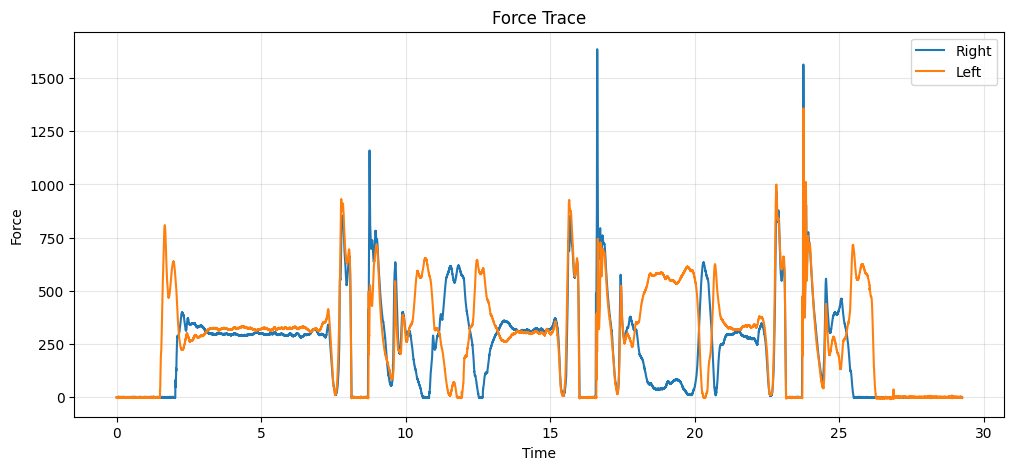

In [28]:
# Visualize force trace (if available)
if force_trace is not None and 'Time' in force_trace.columns:
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(12, 5))
    if 'Right' in force_trace.columns:
        plt.plot(force_trace['Time'], force_trace['Right'], label='Right')
    if 'Left' in force_trace.columns:
        plt.plot(force_trace['Time'], force_trace['Left'], label='Left')
    
    plt.xlabel('Time')
    plt.ylabel('Force')
    plt.title('Force Trace')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Force trace data not available for visualization")